In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans as SklearnKMeans

plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=3, suppress=True)

In [10]:
class KMeans:

    def __init__(self, n_clusters=3, init="kmeans++", max_iter=300,
                 tol=1e-4, random_state=None):
        if init not in ("random", "kmeans++"):
            raise ValueError("init must be 'random' or 'kmeans++'")
        self.n_clusters = n_clusters
        self.init = init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.centroids_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.history_ = []

    def _sq_distances(self, X, C):
        diff = X[:, None, :] - C[None, :, :]
        return np.sum(diff ** 2, axis=2)

    def _init_random(self, X, rng):
        idx = rng.choice(len(X), size=self.n_clusters, replace=False)
        return X[idx].copy()

    def _init_kmeanspp(self, X, rng):
        n = len(X)
        centroids = np.empty((self.n_clusters, X.shape[1]))

        centroids[0] = X[rng.integers(n)]

        closest_sq = self._sq_distances(X, centroids[:1]).ravel()

        for c in range(1, self.n_clusters):
            total = closest_sq.sum()
            if total == 0:
                probs = None
            else:
                probs = closest_sq / total
            idx = rng.choice(n, p=probs)
            centroids[c] = X[idx]

            new_sq = self._sq_distances(X, centroids[c:c + 1]).ravel()
            closest_sq = np.minimum(closest_sq, new_sq)

        return centroids

    def _assign(self, X, C):
        d2 = self._sq_distances(X, C)
        labels = np.argmin(d2, axis=1)
        inertia = d2[np.arange(len(X)), labels].sum()
        return labels, inertia, d2

    def _update(self, X, labels, old_C, d2):
        new_C = np.empty_like(old_C)
        for j in range(self.n_clusters):
            members = X[labels == j]
            if len(members) == 0:
                worst = np.argmax(d2[np.arange(len(X)), labels])
                new_C[j] = X[worst]
            else:
                new_C[j] = members.mean(axis=0)
        return new_C

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        if self.n_clusters > len(X):
            raise ValueError("n_clusters cannot be more than number of samples")

        rng = np.random.default_rng(self.random_state)
        if self.init == "kmeans++":
            C = self._init_kmeanspp(X, rng)
        else:
            C = self._init_random(X, rng)

        self.history_ = []
        for it in range(1, self.max_iter + 1):
            labels, inertia, d2 = self._assign(X, C)
            self.history_.append(inertia)

            new_C = self._update(X, labels, C, d2)
            shift = np.sqrt(np.sum((new_C - C) ** 2))
            C = new_C
            self.n_iter_ = it
            if shift <= self.tol:
                break

        self.labels_, self.inertia_, _ = self._assign(X, C)
        self.centroids_ = C
        return self

    def predict(self, X):
        if self.centroids_ is None:
            raise RuntimeError("Call fit() before predict()")
        labels, _, _ = self._assign(np.asarray(X, dtype=float), self.centroids_)
        return labels

    def fit_predict(self, X):
        return self.fit(X).labels_

    def __repr__(self):
        return (f"KMeans(n_clusters={self.n_clusters}, init='{self.init}', "
                f"max_iter={self.max_iter}, tol={self.tol})")

Data shape: (600, 2)


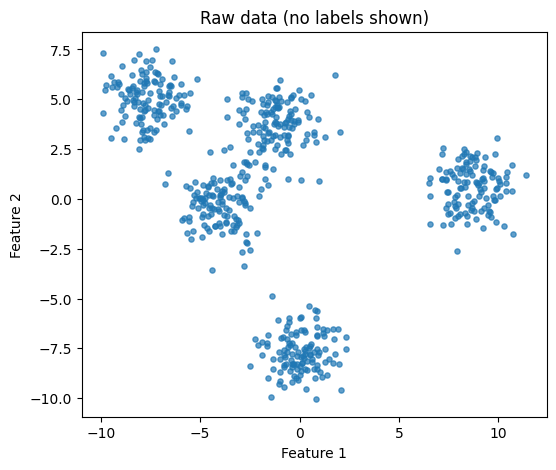

In [11]:
X, y_true = make_blobs(n_samples=600, centers=5, cluster_std=1.1,
                       center_box=(-9, 9), random_state=7)
print("Data shape:", X.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=14, alpha=0.7)
plt.title("Raw data (no labels shown)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()

In [12]:
km = KMeans(n_clusters=5, init="kmeans++", random_state=1)
labels = km.fit_predict(X)

print(km)
print("Iterations taken :", km.n_iter_)
print("Final inertia    :", round(km.inertia_, 2))
print("Centroids:\n", km.centroids_)

KMeans(n_clusters=5, init='kmeans++', max_iter=300, tol=0.0001)
Iterations taken : 5
Final inertia    : 1351.59
Centroids:
 [[-1.182  3.731]
 [ 8.67   0.571]
 [ 0.039 -7.695]
 [-4.031 -0.326]
 [-7.661  5.022]]


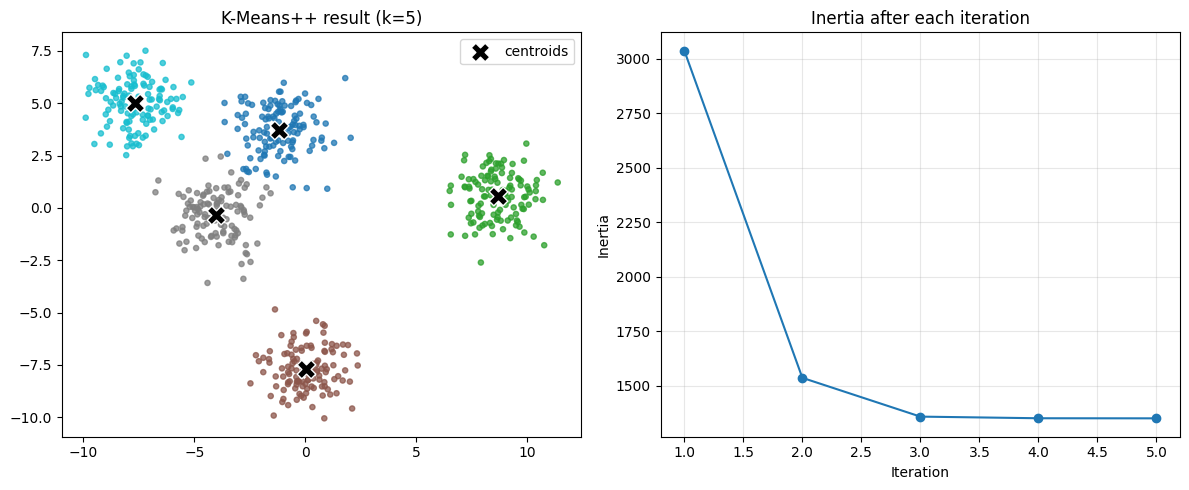

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="tab10", s=14, alpha=0.75)
ax[0].scatter(km.centroids_[:, 0], km.centroids_[:, 1], c="black",
              marker="X", s=180, edgecolor="white", label="centroids")
ax[0].set_title("K-Means++ result (k=5)")
ax[0].legend()

ax[1].plot(range(1, len(km.history_) + 1), km.history_, marker="o")
ax[1].set_title("Inertia after each iteration")
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Inertia")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

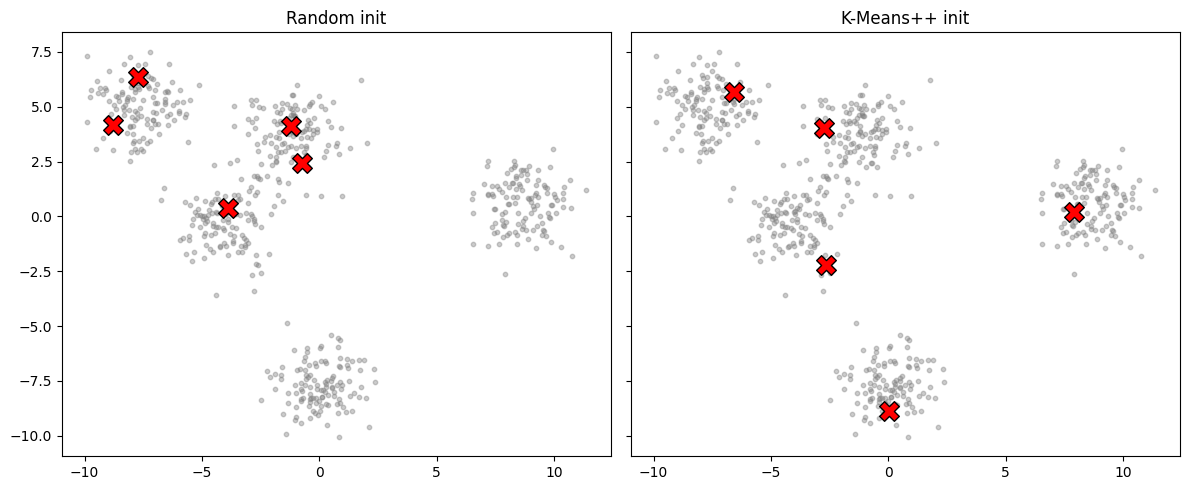

In [14]:
rng_a = np.random.default_rng(3)
rng_b = np.random.default_rng(3)
helper = KMeans(n_clusters=5)

init_rand = helper._init_random(X, rng_a)
init_pp   = helper._init_kmeanspp(X, rng_b)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for a, C, name in zip(ax, [init_rand, init_pp], ["Random init", "K-Means++ init"]):
    a.scatter(X[:, 0], X[:, 1], s=10, alpha=0.4, color="grey")
    a.scatter(C[:, 0], C[:, 1], c="red", marker="X", s=200, edgecolor="black")
    a.set_title(name)
plt.tight_layout(); plt.show()

In [15]:
n_runs = 100
results = {"random": {"inertia": [], "iters": []},
           "kmeans++": {"inertia": [], "iters": []}}

for method in results:
    for seed in range(n_runs):
        model = KMeans(n_clusters=5, init=method, random_state=seed).fit(X)
        results[method]["inertia"].append(model.inertia_)
        results[method]["iters"].append(model.n_iter_)

for method in results:
    inert = np.array(results[method]["inertia"])
    its = np.array(results[method]["iters"])
    print(f"{method:9s} | inertia: mean={inert.mean():8.2f}  std={inert.std():7.2f}  "
          f"best={inert.min():8.2f}  worst={inert.max():8.2f} | avg iters={its.mean():.1f}")

random    | inertia: mean= 2222.23  std=1228.12  best= 1351.51  worst= 9765.04 | avg iters=9.4
kmeans++  | inertia: mean= 1762.78  std= 628.17  best= 1351.51  worst= 2735.03 | avg iters=6.3


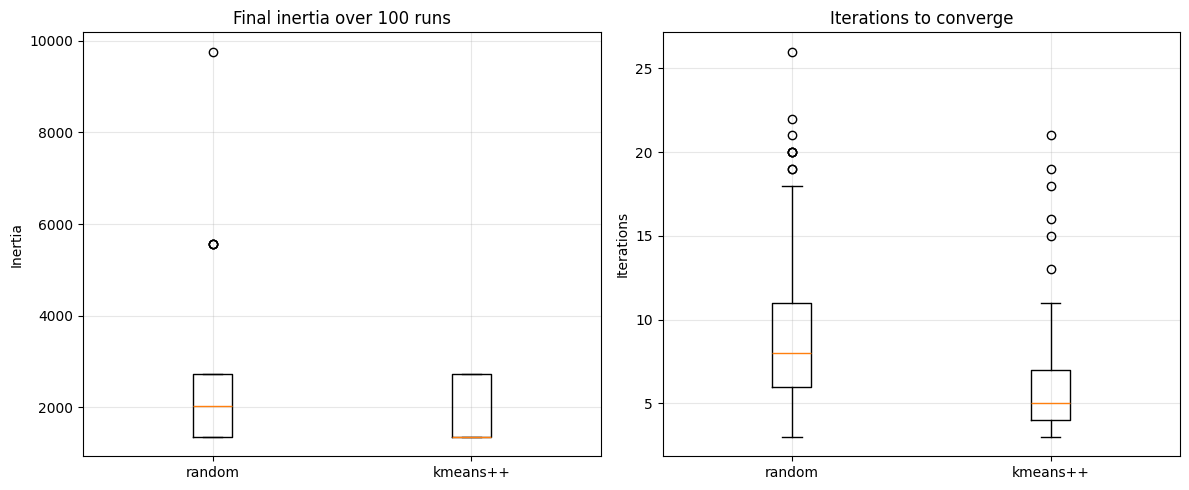

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].boxplot([results["random"]["inertia"], results["kmeans++"]["inertia"]])
ax[0].set_xticklabels(["random", "kmeans++"])
ax[0].set_title("Final inertia over 100 runs")
ax[0].set_ylabel("Inertia")

ax[1].boxplot([results["random"]["iters"], results["kmeans++"]["iters"]])
ax[1].set_xticklabels(["random", "kmeans++"])
ax[1].set_title("Iterations to converge")
ax[1].set_ylabel("Iterations")

for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
best_overall = min(min(results["random"]["inertia"]), min(results["kmeans++"]["inertia"]))
for method in results:
    inert = np.array(results[method]["inertia"])
    bad = np.mean(inert > 1.05 * best_overall) * 100
    print(f"{method:9s}: {bad:.0f}% of runs ended in a bad solution")

random   : 50% of runs ended in a bad solution
kmeans++ : 30% of runs ended in a bad solution


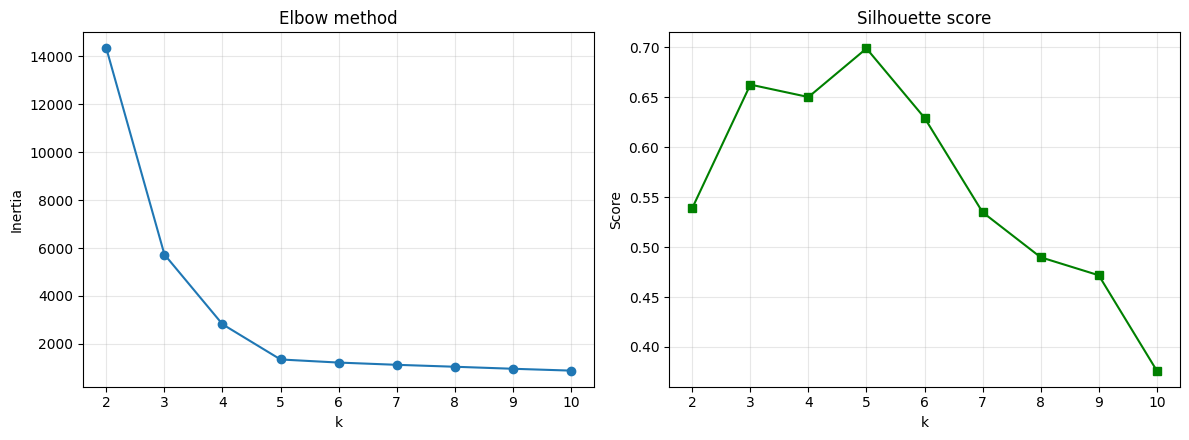

k with best silhouette: 5


In [18]:
def best_of(X, k, n_init=10):
    best = None
    for s in range(n_init):
        m = KMeans(n_clusters=k, init="kmeans++", random_state=s).fit(X)
        if best is None or m.inertia_ < best.inertia_:
            best = m
    return best

ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    m = best_of(X, k)
    inertias.append(m.inertia_)
    sils.append(silhouette_score(X, m.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(list(ks), inertias, marker="o")
ax[0].set_title("Elbow method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")

ax[1].plot(list(ks), sils, marker="s", color="green")
ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")

for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("k with best silhouette:", list(ks)[int(np.argmax(sils))])

In [19]:
mine = best_of(X, 5, n_init=10)

sk = SklearnKMeans(n_clusters=5, init="k-means++", n_init=10, random_state=0).fit(X)

print(f"My implementation : inertia = {mine.inertia_:.3f}")
print(f"scikit-learn      : inertia = {sk.inertia_:.3f}")
print("Difference        :", abs(mine.inertia_ - sk.inertia_))

a = mine.centroids_[np.lexsort(mine.centroids_.T)]
b = sk.cluster_centers_[np.lexsort(sk.cluster_centers_.T)]
print("\nMax centroid difference:", np.abs(a - b).max())

My implementation : inertia = 1351.512
scikit-learn      : inertia = 1351.512
Difference        : 4.547473508864641e-13

Max centroid difference: 3.552713678800501e-15


In [20]:
new_points = np.array([[0.0, 0.0], [5.0, 5.0], [-6.0, 4.0]])
print("Assigned clusters:", mine.predict(new_points))

Assigned clusters: [3 1 2]
